# 🛍️ Hệ thống Phân loại Cảm xúc Bình luận Thương mại Điện tử
**Môn học:** Khai thác Dữ liệu (Data Mining)  
**Ngành:** Công nghệ Thông tin  
**Dataset:** Vietnamese Sentiment Analyst (Kaggle — linhlpv)  
**Nhãn:** POS (Tích cực) / NEG (Tiêu cực) / NEU (Trung tính)

---
## 📋 Lộ trình
1. Khám phá dữ liệu (EDA)
2. Tiền xử lý văn bản
3. Baseline Models (Naive Bayes, Logistic Regression, SVM)
4. Fine-tune PhoBERT (cần GPU)
5. So sánh & kết luận

---
## ⚙️ Cài đặt thư viện

In [9]:
!pip install pyvi transformers sentencepiece -q

---
## 📦 Import thư viện

In [10]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from pyvi import ViTokenizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
os.makedirs('/kaggle/working/data',   exist_ok=True)
os.makedirs('/kaggle/working/models', exist_ok=True)

# Hằng số đường dẫn
DATA_PATH   = '/kaggle/input/datasets/linhlpv/vietnamese-sentiment-analyst/data.csv'
PROC_PATH   = '/kaggle/working/data/processed.csv'
MODEL_DIR   = '/kaggle/working/models'

# Màu sắc cho biểu đồ
COLORS = {'POS': '#2ecc71', 'NEG': '#e74c3c', 'NEU': '#95a5a6'}
CLASS_NAMES = ['Tiêu cực (NEG)', 'Trung tính (NEU)', 'Tích cực (POS)']
LABEL_MAP   = {'POS': 2, 'NEU': 1, 'NEG': 0}

print('✅ Import xong!')

✅ Import xong!


---
## 1️⃣ Khám phá Dữ liệu (EDA)

In [11]:
df = pd.read_csv(DATA_PATH)

print('=== Thông tin tổng quan ===')
print(f'Shape     : {df.shape}')
print(f'Cột       : {df.columns.tolist()}')
print(f'Thiếu dữ liệu:\n{df.isnull().sum()}')
print(f'\nPhân phối nhãn:\n{df["label"].value_counts()}')
df.head(10)

=== Thông tin tổng quan ===
Shape     : (31460, 3)
Cột       : ['content', 'label', 'start']
Thiếu dữ liệu:
content    24
label       0
start       0
dtype: int64

Phân phối nhãn:
label
POS    20093
NEG     6669
NEU     4698
Name: count, dtype: int64


,content,label,start
0,Áo bao đẹp ạ!,POS,5
1,Tuyệt vời,POS,5
2,2day ao khong giong trong,NEG,1
3,"Mùi thơm,bôi lên da mềm da",POS,5
4,"Vải đẹp, dày dặn",POS,5
5,"Hàng rất đẹp, rất chi là ưng ý",POS,5
6,"Chất lượng sản phẩm tốt, date dài",POS,5
7,Ăn nói và thái độ phục vụ tốt,POS,4
8,Đóng gói sản phẩm chắc chắn,POS,5
9,tất sờn hết ca chưa dùng mà vay r,NEG,2


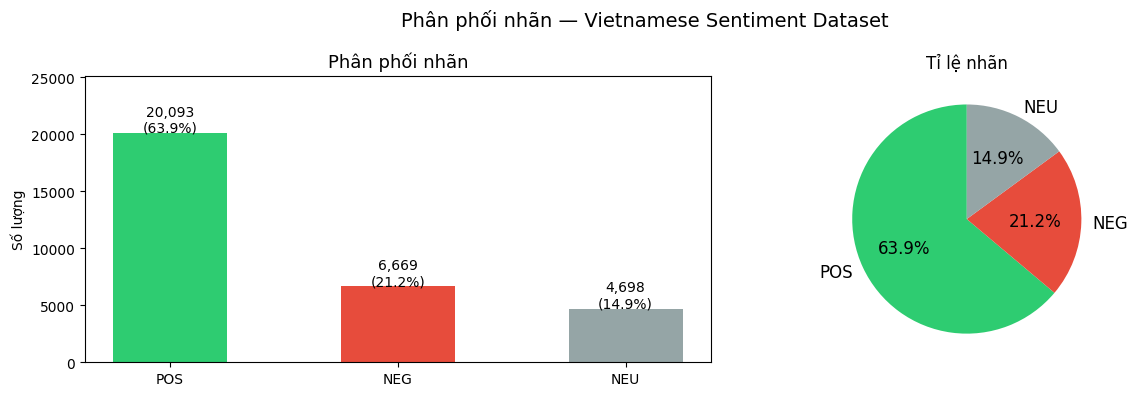

In [12]:
# --- Biểu đồ phân phối nhãn ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
counts = df['label'].value_counts()

bars = axes[0].bar(counts.index, counts.values,
                   color=[COLORS[l] for l in counts.index], width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}\n({val/len(df):.1%})', ha='center', fontsize=10)
axes[0].set_title('Phân phối nhãn', fontsize=13)
axes[0].set_ylabel('Số lượng')
axes[0].set_ylim(0, counts.max() * 1.25)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=[COLORS[l] for l in counts.index],
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Tỉ lệ nhãn')

plt.suptitle('Phân phối nhãn — Vietnamese Sentiment Dataset', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/01_label_distribution.png', dpi=150)
plt.show()

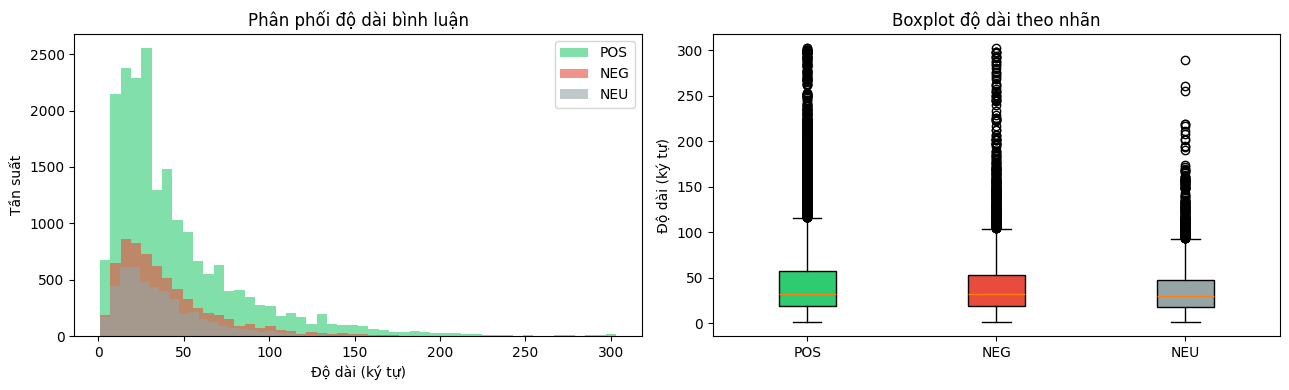

         count  mean   std  min   25%   50%   75%    max
label                                                   
NEG     6669.0  42.3  36.0  1.0  19.0  32.0  53.0  303.0
NEU     4698.0  37.7  29.0  1.0  18.0  30.0  48.0  289.0
POS    20093.0  45.8  41.1  1.0  19.0  32.0  58.0  303.0


In [13]:
# --- Phân tích độ dài bình luận ---
df['text_length'] = df['content'].astype(str).apply(len)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, color in COLORS.items():
    subset = df[df['label'] == label]['text_length']
    axes[0].hist(subset, bins=50, alpha=0.6, label=label, color=color)
axes[0].set_xlabel('Độ dài (ký tự)')
axes[0].set_ylabel('Tần suất')
axes[0].set_title('Phân phối độ dài bình luận')
axes[0].legend()

data_plot = [df[df['label'] == l]['text_length'].values for l in ['POS', 'NEG', 'NEU']]
bp = axes[1].boxplot(data_plot, labels=['POS', 'NEG', 'NEU'], patch_artist=True)
for patch, color in zip(bp['boxes'], COLORS.values()):
    patch.set_facecolor(color)
axes[1].set_title('Boxplot độ dài theo nhãn')
axes[1].set_ylabel('Độ dài (ký tự)')

plt.tight_layout()
plt.savefig('/kaggle/working/02_text_length.png', dpi=150)
plt.show()

print(df.groupby('label')['text_length'].describe().round(1))

In [14]:
# --- Xem mẫu từng nhãn ---
for label in ['POS', 'NEG', 'NEU']:
    print(f"\n{'='*55}")
    print(f"  {label} — 3 mẫu ngẫu nhiên")
    print('='*55)
    for text in df[df['label'] == label]['content'].sample(3, random_state=42):
        print(f"  • {text}")


  POS — 3 mẫu ngẫu nhiên
  • Áo đẹp với lại chất rất Ok hihi thái độ phục vụ rất tốt ak !
  • Chất lượng sản phẩm tốt
  • Đẹp lắm dù thời gian giao hàng hơi lâu ❤️

  NEG — 3 mẫu ngẫu nhiên
  • Shop phục vụ rất kém
  • Nt đổi mẫu khách chưa đồng ý mà tự đổi
  • Đóng nhầm hàg rất nhiều lần

  NEU — 3 mẫu ngẫu nhiên
  • Tạm đc Thời gian giao hàng rất nhanh
  • Vai đep,kieu dang đep ,nhung minh mua 1cai sezi L va 1 cai size m ,nhung giao giong nhau đieu size L het
  • Giao hàng hơi chậm ,vải không phải chất liệu voan


---
## 2️⃣ Tiền xử lý Văn bản

In [15]:
STOPWORDS = set([
    'và', 'của', 'là', 'có', 'để', 'trong', 'với', 'này', 'đó',
    'cho', 'được', 'một', 'các', 'khi', 'đã', 'thì', 'mà',
    'hay', 'hoặc', 'nếu', 'vì', 'nhưng', 'tuy', 'dù', 'cũng',
    'rất', 'lắm', 'quá', 'hơn', 'nhất', 'bị', 'làm', 'theo'
])

def preprocess(text):
    if not isinstance(text, str) or text.strip() == '':
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # Xóa URL
    text = re.sub(r'[^\w\s]', ' ', text)              # Xóa ký tự đặc biệt
    text = re.sub(r'\d+', '', text)                   # Xóa số
    text = re.sub(r'\s+', ' ', text).strip()          # Xóa khoảng trắng thừa
    text = ViTokenizer.tokenize(text)                 # Tách từ tiếng Việt
    tokens = [t for t in text.split()
              if t not in STOPWORDS and len(t) > 1]
    return ' '.join(tokens)

# Kiểm tra hàm
test_cases = [
    'Sản phẩm rất tốt, giao hàng nhanh!!!',
    'Màu không giống hình, chất vải kém lắm',
    'Tạm được, không tốt cũng không tệ lắm'
]
for t in test_cases:
    print(f'  Gốc : {t}')
    print(f'  Sau : {preprocess(t)}')
    print()

  Gốc : Sản phẩm rất tốt, giao hàng nhanh!!!
  Sau : sản_phẩm tốt giao hàng nhanh

  Gốc : Màu không giống hình, chất vải kém lắm
  Sau : màu không giống hình chất vải kém

  Gốc : Tạm được, không tốt cũng không tệ lắm
  Sau : tạm không tốt không tệ



In [16]:
# Áp dụng tiền xử lý
df['label_id']   = df['label'].map(LABEL_MAP)

print('Đang xử lý văn bản (mất ~3-5 phút)...')
df['text_clean'] = df['content'].apply(preprocess)

before = len(df)
df = df[df['text_clean'].str.len() > 5].reset_index(drop=True)
print(f'Loại bỏ {before - len(df)} dòng rỗng/quá ngắn')
print(f'Còn lại: {len(df):,} mẫu')
print(f'\nPhân phối nhãn sau xử lý:\n{df["label"].value_counts()}')

df[['content', 'text_clean', 'label', 'label_id']].to_csv(PROC_PATH, index=False)
print(f'\n✅ Đã lưu: {PROC_PATH}')
df[['content', 'text_clean', 'label', 'label_id']].head()

Đang xử lý văn bản (mất ~3-5 phút)...
Loại bỏ 866 dòng rỗng/quá ngắn
Còn lại: 30,594 mẫu

Phân phối nhãn sau xử lý:
label
POS    19541
NEG     6530
NEU     4523
Name: count, dtype: int64

✅ Đã lưu: /kaggle/working/data/processed.csv


,content,text_clean,label,label_id
0,Áo bao đẹp ạ!,áo bao đẹp,POS,2
1,Tuyệt vời,tuyệt_vời,POS,2
2,2day ao khong giong trong,day ao khong giong,NEG,0
3,"Mùi thơm,bôi lên da mềm da",mùi thơm bôi lên da mềm da,POS,2
4,"Vải đẹp, dày dặn",vải đẹp dày_dặn,POS,2


---
## 3️⃣ Baseline Models — Naive Bayes / Logistic Regression / SVM

In [17]:
df = pd.read_csv(PROC_PATH)
X  = df['text_clean']
y  = df['label_id']   # 0=NEG, 1=NEU, 2=POS

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {len(X_train):,} mẫu')
print(f'Test  : {len(X_test):,} mẫu')
print(f'Phân phối train: {pd.Series(y_train).value_counts().sort_index().to_dict()}')

Train : 24,475 mẫu
Test  : 6,119 mẫu
Phân phối train: {0: 5224, 1: 3618, 2: 15633}


In [18]:
models = {
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2))),
        ('clf',   MultinomialNB(alpha=0.1))
    ]),
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2))),
        ('clf',   LogisticRegression(max_iter=500, C=1.0, class_weight='balanced'))
    ]),
    'SVM (Linear)': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2))),
        ('clf',   LinearSVC(C=1.0, max_iter=2000, class_weight='balanced'))
    ]),
}

results      = {}
all_preds    = {}

for name, model in models.items():
    print(f"\n{'='*52}\n  {name}\n{'='*52}")
    model.fit(X_train, y_train)
    y_pred       = model.predict(X_test)
    acc          = accuracy_score(y_test, y_pred)
    results[name]   = acc
    all_preds[name] = y_pred
    print(f'Accuracy: {acc:.4f} ({acc:.2%})')
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))


  Naive Bayes
Accuracy: 0.7612 (76.12%)
                  precision    recall  f1-score   support

  Tiêu cực (NEG)       0.65      0.72      0.68      1306
Trung tính (NEU)       0.36      0.22      0.27       905
  Tích cực (POS)       0.86      0.90      0.88      3908

        accuracy                           0.76      6119
       macro avg       0.62      0.61      0.61      6119
    weighted avg       0.74      0.76      0.75      6119


  Logistic Regression
Accuracy: 0.7286 (72.86%)
                  precision    recall  f1-score   support

  Tiêu cực (NEG)       0.65      0.70      0.67      1306
Trung tính (NEU)       0.32      0.45      0.37       905
  Tích cực (POS)       0.92      0.80      0.85      3908

        accuracy                           0.73      6119
       macro avg       0.63      0.65      0.63      6119
    weighted avg       0.77      0.73      0.74      6119


  SVM (Linear)
Accuracy: 0.7516 (75.16%)
                  precision    recall  f1-score   

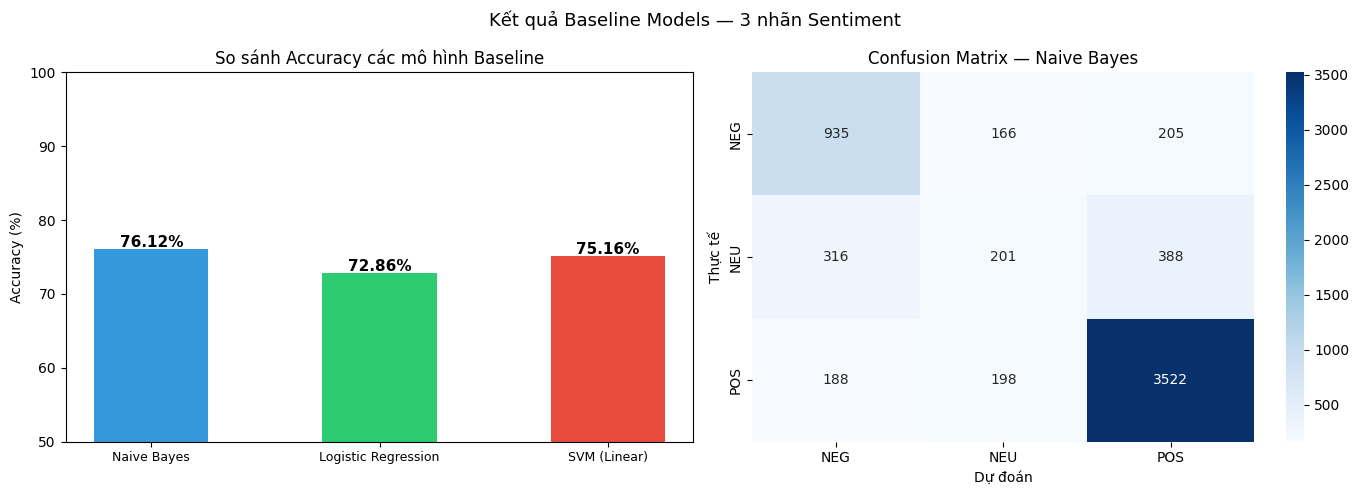


🏆 Model tốt nhất: Naive Bayes (76.12%)
✅ Đã lưu: /kaggle/working/models/best_baseline.pkl


In [19]:
# --- Biểu đồ so sánh & Confusion Matrix ---
best_name  = max(results, key=results.get)
best_model = models[best_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart accuracy
bar_colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = axes[0].bar(results.keys(), [v * 100 for v in results.values()],
                   color=bar_colors, width=0.5)
for bar, val in zip(bars, results.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3, f'{val:.2%}',
                 ha='center', fontweight='bold', fontsize=11)
axes[0].set_ylim(50, 100)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('So sánh Accuracy các mô hình Baseline')
axes[0].tick_params(axis='x', labelsize=9)

# Confusion matrix của model tốt nhất
cm = confusion_matrix(y_test, all_preds[best_name])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['NEG', 'NEU', 'POS'],
            yticklabels=['NEG', 'NEU', 'POS'])
axes[1].set_title(f'Confusion Matrix — {best_name}')
axes[1].set_ylabel('Thực tế')
axes[1].set_xlabel('Dự đoán')

plt.suptitle('Kết quả Baseline Models — 3 nhãn Sentiment', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/03_baseline_results.png', dpi=150)
plt.show()

print(f'\n🏆 Model tốt nhất: {best_name} ({results[best_name]:.2%})')
joblib.dump(best_model, f'{MODEL_DIR}/best_baseline.pkl')
print(f'✅ Đã lưu: {MODEL_DIR}/best_baseline.pkl')

---
## 4️⃣ Fine-tune PhoBERT (GPU)
> ⚠️ **Bật GPU trước**: Settings → Accelerator → GPU T4 x2

In [20]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (AutoTokenizer,
                          AutoModelForSequenceClassification,
                          get_linear_schedule_with_warmup)
from torch.optim import AdamW

# Kiểm tra GPU
if torch.cuda.is_available():
    print(f'✅ GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('❌ Không có GPU! Hãy bật GPU trong Settings trước khi chạy cell này.')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

✅ GPU: Tesla T4
   VRAM: 15.6 GB


In [22]:
# Dataset class
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [23]:
# Load dữ liệu & chuẩn bị DataLoader
df_bert = pd.read_csv(PROC_PATH)

# PhoBERT dùng text gốc (không qua ViTokenizer thủ công)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    df_bert['content'].tolist(),
    df_bert['label_id'].tolist(),
    test_size=0.2, random_state=42, stratify=df_bert['label_id']
)

MODEL_NAME = 'vinai/phobert-base-v2'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

BATCH_SIZE = 32
train_loader = DataLoader(
    SentimentDataset(X_train_b, y_train_b, tokenizer),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)
test_loader = DataLoader(
    SentimentDataset(X_test_b, y_test_b, tokenizer),
    batch_size=BATCH_SIZE, num_workers=2
)
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches: 765 | Test batches: 192


In [24]:
# Load PhoBERT model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3   # 3 nhãn: NEG / NEU / POS
)
model = model.to(device)

# Optimizer + Scheduler
EPOCHS    = 3
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=len(train_loader) // 5,
    num_training_steps=len(train_loader) * EPOCHS
)

# Loss có trọng số để xử lý mất cân bằng nhãn
weights      = compute_class_weight('balanced',
                                    classes=np.array([0, 1, 2]),
                                    y=y_train_b)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)
loss_fn      = torch.nn.CrossEntropyLoss(weight=class_weights)

print(f'Class weights: NEG={weights[0]:.2f}, NEU={weights[1]:.2f}, POS={weights[2]:.2f}')
print('✅ Sẵn sàng train!')

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

Class weights: NEG=1.56, NEU=2.25, POS=0.52
✅ Sẵn sàng train!


In [25]:
# Training loop
history = {'train_loss': [], 'val_acc': []}
best_acc = 0.0

for epoch in range(EPOCHS):
    # ---- Train ----
    model.train()
    total_loss = 0
    for i, batch in enumerate(train_loader):
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = loss_fn(outputs.logits, labels)
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        if (i + 1) % 50 == 0:
            print(f'  Epoch {epoch+1} | Step {i+1}/{len(train_loader)} '
                  f'| Loss: {total_loss/(i+1):.4f}')

    avg_loss = total_loss / len(train_loader)
    history['train_loss'].append(avg_loss)

    # ---- Evaluate ----
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in test_loader:
            out   = model(input_ids=batch['input_ids'].to(device),
                          attention_mask=batch['attention_mask'].to(device))
            preds += out.logits.argmax(dim=1).cpu().tolist()
            trues += batch['label'].tolist()

    acc = accuracy_score(trues, preds)
    history['val_acc'].append(acc)
    print(f'\n✅ Epoch {epoch+1}/{EPOCHS} '
          f'| Avg Loss: {avg_loss:.4f} | Accuracy: {acc:.4f}\n')

    # Lưu model tốt nhất
    if acc > best_acc:
        best_acc = acc
        model.save_pretrained(f'{MODEL_DIR}/phobert_best')
        tokenizer.save_pretrained(f'{MODEL_DIR}/phobert_best')
        print(f'  💾 Đã lưu model tốt nhất (Accuracy: {best_acc:.4f})')

print('\n=== Kết quả PhoBERT ===')
print(classification_report(trues, preds, target_names=CLASS_NAMES))

  Epoch 1 | Step 50/765 | Loss: 1.0913
  Epoch 1 | Step 100/765 | Loss: 1.0544
  Epoch 1 | Step 150/765 | Loss: 0.9678
  Epoch 1 | Step 200/765 | Loss: 0.9135
  Epoch 1 | Step 250/765 | Loss: 0.8809
  Epoch 1 | Step 300/765 | Loss: 0.8541
  Epoch 1 | Step 350/765 | Loss: 0.8359
  Epoch 1 | Step 400/765 | Loss: 0.8177
  Epoch 1 | Step 450/765 | Loss: 0.8004
  Epoch 1 | Step 500/765 | Loss: 0.7912
  Epoch 1 | Step 550/765 | Loss: 0.7793
  Epoch 1 | Step 600/765 | Loss: 0.7685
  Epoch 1 | Step 650/765 | Loss: 0.7608
  Epoch 1 | Step 700/765 | Loss: 0.7540
  Epoch 1 | Step 750/765 | Loss: 0.7460

✅ Epoch 1/3 | Avg Loss: 0.7436 | Accuracy: 0.7732



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  💾 Đã lưu model tốt nhất (Accuracy: 0.7732)
  Epoch 2 | Step 50/765 | Loss: 0.6216
  Epoch 2 | Step 100/765 | Loss: 0.6212
  Epoch 2 | Step 150/765 | Loss: 0.6222
  Epoch 2 | Step 200/765 | Loss: 0.6106
  Epoch 2 | Step 250/765 | Loss: 0.6134
  Epoch 2 | Step 300/765 | Loss: 0.6086
  Epoch 2 | Step 350/765 | Loss: 0.6086
  Epoch 2 | Step 400/765 | Loss: 0.6116
  Epoch 2 | Step 450/765 | Loss: 0.6074
  Epoch 2 | Step 500/765 | Loss: 0.6064
  Epoch 2 | Step 550/765 | Loss: 0.6080
  Epoch 2 | Step 600/765 | Loss: 0.6085
  Epoch 2 | Step 650/765 | Loss: 0.6054
  Epoch 2 | Step 700/765 | Loss: 0.6031
  Epoch 2 | Step 750/765 | Loss: 0.6017

✅ Epoch 2/3 | Avg Loss: 0.6010 | Accuracy: 0.7822



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  💾 Đã lưu model tốt nhất (Accuracy: 0.7822)
  Epoch 3 | Step 50/765 | Loss: 0.5344
  Epoch 3 | Step 100/765 | Loss: 0.5538
  Epoch 3 | Step 150/765 | Loss: 0.5439
  Epoch 3 | Step 200/765 | Loss: 0.5392
  Epoch 3 | Step 250/765 | Loss: 0.5456
  Epoch 3 | Step 300/765 | Loss: 0.5417
  Epoch 3 | Step 350/765 | Loss: 0.5418
  Epoch 3 | Step 400/765 | Loss: 0.5430
  Epoch 3 | Step 450/765 | Loss: 0.5399
  Epoch 3 | Step 500/765 | Loss: 0.5390
  Epoch 3 | Step 550/765 | Loss: 0.5361
  Epoch 3 | Step 600/765 | Loss: 0.5396
  Epoch 3 | Step 650/765 | Loss: 0.5385
  Epoch 3 | Step 700/765 | Loss: 0.5346
  Epoch 3 | Step 750/765 | Loss: 0.5359

✅ Epoch 3/3 | Avg Loss: 0.5363 | Accuracy: 0.7851



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  💾 Đã lưu model tốt nhất (Accuracy: 0.7851)

=== Kết quả PhoBERT ===
                  precision    recall  f1-score   support

  Tiêu cực (NEG)       0.76      0.77      0.76      1306
Trung tính (NEU)       0.38      0.52      0.44       905
  Tích cực (POS)       0.94      0.85      0.89      3908

        accuracy                           0.79      6119
       macro avg       0.69      0.71      0.70      6119
    weighted avg       0.82      0.79      0.80      6119



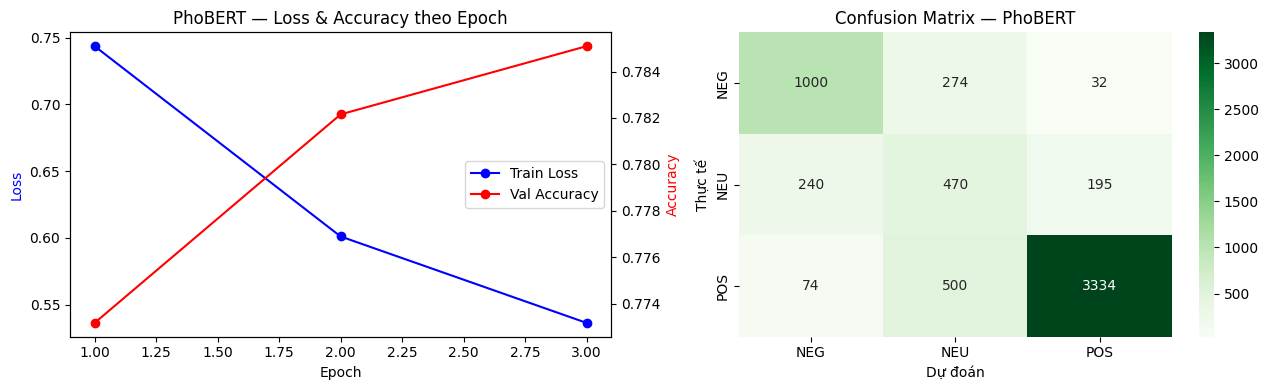

In [26]:
# --- Biểu đồ kết quả PhoBERT ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss & Accuracy qua các epoch
epochs_range = range(1, EPOCHS + 1)
ax1 = axes[0]
ax2 = ax1.twinx()
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
ax2.plot(epochs_range, history['val_acc'],    'r-o', label='Val Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss',     color='blue')
ax2.set_ylabel('Accuracy', color='red')
ax1.set_title('PhoBERT — Loss & Accuracy theo Epoch')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

# Confusion matrix PhoBERT
cm_bert = confusion_matrix(trues, preds)
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['NEG', 'NEU', 'POS'],
            yticklabels=['NEG', 'NEU', 'POS'])
axes[1].set_title('Confusion Matrix — PhoBERT')
axes[1].set_ylabel('Thực tế')
axes[1].set_xlabel('Dự đoán')

plt.tight_layout()
plt.savefig('/kaggle/working/04_phobert_results.png', dpi=150)
plt.show()

---
## 5️⃣ So sánh Tổng hợp Tất cả Mô hình

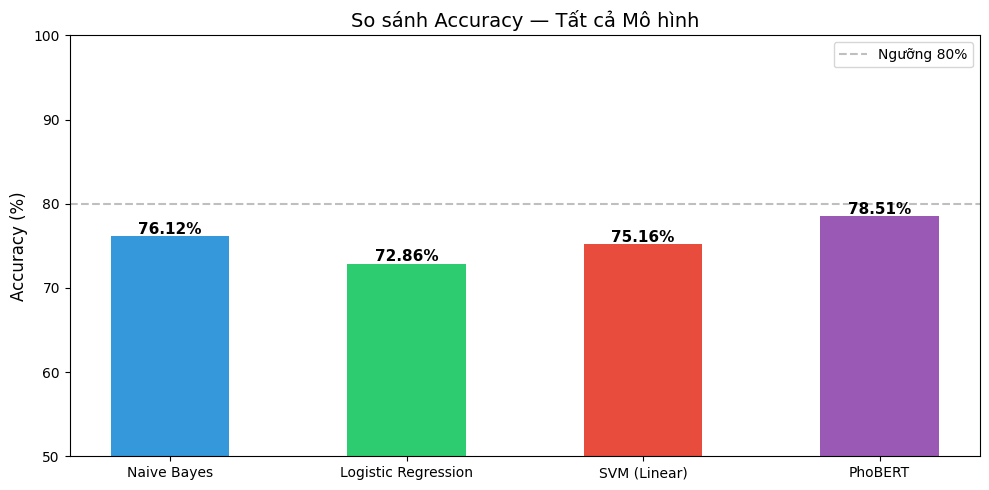


=== BẢNG TỔNG HỢP KẾT QUẢ ===
            Mô hình Accuracy Accuracy (%)
        Naive Bayes   0.7612       76.12%
Logistic Regression   0.7286       72.86%
       SVM (Linear)   0.7516       75.16%
            PhoBERT   0.7851       78.51%

🏆 Model tốt nhất tổng thể: PhoBERT (78.51%)


In [27]:
# Tổng hợp kết quả tất cả models
phobert_acc = best_acc

all_results = {
    **results,          # Naive Bayes, LR, SVM
    'PhoBERT': phobert_acc
}

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
bars = ax.bar(all_results.keys(),
              [v * 100 for v in all_results.values()],
              color=bar_colors, width=0.5)

for bar, val in zip(bars, all_results.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.2%}',
            ha='center', fontweight='bold', fontsize=11)

ax.set_ylim(50, 100)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('So sánh Accuracy — Tất cả Mô hình', fontsize=14)
ax.axhline(y=80, color='gray', linestyle='--', alpha=0.5, label='Ngưỡng 80%')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('/kaggle/working/05_final_comparison.png', dpi=150)
plt.show()

# Bảng tổng hợp
print('\n=== BẢNG TỔNG HỢP KẾT QUẢ ===')
summary = pd.DataFrame({
    'Mô hình': list(all_results.keys()),
    'Accuracy': [f'{v:.4f}' for v in all_results.values()],
    'Accuracy (%)': [f'{v:.2%}' for v in all_results.values()]
})
print(summary.to_string(index=False))

best_overall = max(all_results, key=all_results.get)
print(f'\n🏆 Model tốt nhất tổng thể: {best_overall} ({all_results[best_overall]:.2%})')

In [28]:
# --- Demo dự đoán thực tế ---
print('=== DEMO DỰ ĐOÁN (Baseline Model) ===\n')
label_decode = {2: '✅ TÍCH CỰC (POS)', 1: '😐 TRUNG TÍNH (NEU)', 0: '❌ TIÊU CỰC (NEG)'}

test_comments = [
    'Sản phẩm đẹp lắm, giao hàng siêu nhanh, đóng gói cẩn thận!',
    'Hàng không giống hình, chất liệu kém, rất thất vọng',
    'Tạm ổn, không có gì đặc biệt lắm',
    'Mua lần 2 rồi, chất lượng ổn định, sẽ ủng hộ tiếp',
    'Giao hàng chậm, hàng bị móp méo, không hài lòng chút nào'
]

best_bl = joblib.load(f'{MODEL_DIR}/best_baseline.pkl')

for comment in test_comments:
    cleaned = preprocess(comment)
    pred    = best_bl.predict([cleaned])[0]
    print(f'  Bình luận : {comment}')
    print(f'  Kết quả   : {label_decode[pred]}')
    print()

=== DEMO DỰ ĐOÁN (Baseline Model) ===

  Bình luận : Sản phẩm đẹp lắm, giao hàng siêu nhanh, đóng gói cẩn thận!
  Kết quả   : ✅ TÍCH CỰC (POS)

  Bình luận : Hàng không giống hình, chất liệu kém, rất thất vọng
  Kết quả   : ❌ TIÊU CỰC (NEG)

  Bình luận : Tạm ổn, không có gì đặc biệt lắm
  Kết quả   : 😐 TRUNG TÍNH (NEU)

  Bình luận : Mua lần 2 rồi, chất lượng ổn định, sẽ ủng hộ tiếp
  Kết quả   : ✅ TÍCH CỰC (POS)

  Bình luận : Giao hàng chậm, hàng bị móp méo, không hài lòng chút nào
  Kết quả   : ❌ TIÊU CỰC (NEG)



---
## 📁 Tổng hợp file output

In [29]:
print('=== CÁC FILE ĐÃ TẠO ===')
for root, dirs, files in os.walk('/kaggle/working/'):
    for f in sorted(files):
        full = os.path.join(root, f)
        size = os.path.getsize(full)
        print(f'  {full}  ({size/1024:.1f} KB)')

=== CÁC FILE ĐÃ TẠO ===
  /kaggle/working/01_label_distribution.png  (71.3 KB)
  /kaggle/working/02_text_length.png  (62.8 KB)
  /kaggle/working/03_baseline_results.png  (89.0 KB)
  /kaggle/working/04_phobert_results.png  (97.6 KB)
  /kaggle/working/05_final_comparison.png  (51.5 KB)
  /kaggle/working/data/processed.csv  (3540.4 KB)
  /kaggle/working/models/best_baseline.pkl  (1729.7 KB)
  /kaggle/working/models/phobert_best/added_tokens.json  (0.0 KB)
  /kaggle/working/models/phobert_best/bpe.codes  (1108.6 KB)
  /kaggle/working/models/phobert_best/config.json  (0.9 KB)
  /kaggle/working/models/phobert_best/model.safetensors  (527369.6 KB)
  /kaggle/working/models/phobert_best/tokenizer_config.json  (1.2 KB)
  /kaggle/working/models/phobert_best/vocab.txt  (874.3 KB)
  /kaggle/working/.virtual_documents/__notebook_source__.ipynb  (16.7 KB)


In [30]:
import shutil

# Nén thư mục PhoBERT thành zip
shutil.make_archive('/kaggle/working/phobert_best', 'zip',
                    '/kaggle/working/models/phobert_best')
print("✅ Đã tạo phobert_best.zip")

# Kiểm tra kích thước
import os
size = os.path.getsize('/kaggle/working/phobert_best.zip')
print(f"Kích thước: {size/1024/1024:.1f} MB")

✅ Đã tạo phobert_best.zip
Kích thước: 479.4 MB
